In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rasterio as rio
import rioxarray as rxr
import matplotlib.pyplot as plt
from glob import glob
import re

In [3]:
## set date
date = "20230216"

In [56]:
## function for calculating swe statistics for polygons

def swe_stat_calc(raster, shapefile_gdf):
    """
    Calculates snow water equivalent mean, median, and volume for each 
    polygon in a shapefile and returns it as a dataframe.

    Parameters:
    raster (xarray.DataArray): An xarray object with SWE raster data. Units must be in inches.
    shapefile_gdf (geopandas.GeoDataFrame): A GeoDataFrame with shapefile data.

    Returns:
    pandas.DataFrame: A DataFrame with one row for each polygon in shapefile and columns
                        for median, mean, and total swe volume. Mean and median units are
                        in inches and volume units are acre feet.
    """

    cols_swe = ['name', 'Median SWE (in.)', 'Mean SWE (in.)', 
                'Estimated Volume (af)'] #output column names
    swe_df = [] #empty list for polygon stats

    ## loop through each polygon in shapefile and append statistics to swe_df list
    for idx, basin in shapefile_gdf.iterrows():
        swe_basin = raster.rio.clip([basin.geometry])
        
        '''
        ## plot clipped polygon
        f, ax = plt.subplots()
        swe_basin.plot(cmap="Blues",
                        ax=ax)
        plt.show()'
        '''
        swe_median = np.nanmedian(swe_basin) # median swe for basin
        swe_mean = np.nanmean(swe_basin) # mean swe for basin
        swe_sum_inches = np.nansum(swe_basin) # swe sum for basin

        ## get pixel area in feet
        pixel_size_x, pixel_size_y = swe_basin.rio.resolution()
        pixel_area = abs((pixel_size_x*3.28084) * (pixel_size_y*3.28084))
        
        swe_vol_cuft = (swe_sum_inches / 12) * pixel_area # volume in cubic feet
        swe_vol_af = swe_vol_cuft / 43560 # volume in acre feet

        #swe_volume = swe_sum_inches/12 * pd.notnull(swe_basin).sum() / 247.105
        #print(pd.notnull(swe_basin).sum() * 247.105)

        ## append values to list
        swe_df.append([basin['Name'], swe_median, 
                    swe_mean, swe_vol_af,])

    ## convert list to dataframe
    swe_df_table = pd.DataFrame(swe_df, columns=cols_swe)
    return(swe_df_table)

## Read raster and shapefile data

In [38]:
# Read/clip data
snodas_file = "../data/SNODAS/SNODAS_SWE_" + date + ".tif"
snodas = rxr.open_rasterio(snodas_file).sel(band=1).reset_coords('band', drop=True)
snodas_utm = snodas.rio.reproject('epsg:26913', resolution=1000)
huc6 = gpd.read_file('../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp').to_crs('epsg:26913')
huc8 = gpd.read_file('../data/Shapefiles/WBDHU8_RG/WBDHU8_RG.shp').to_crs('epsg:26913')
huc8 = huc8.drop(huc8.index[72]) #remove Rio Salado polygon in Mexico
ose = gpd.read_file('../data/Shapefiles/OSE_Basin_Designations/SubBasins_Dissolve.shp').to_crs('epsg:26913')

In [39]:
## filter data to polygons of interest
huc6_polys = ['Rio Grande Headwaters', 'Upper Rio Grande',
       'Rio Grande-Elephant Butte']
huc6 = huc6[huc6['Name'].isin(huc6_polys)]

huc8['Name'].unique()
huc8_polys = ['Rio Grande Headwaters', 'Alamosa-Trinchera',
              'San Luis', 'Saguache',
              'Conejos', 'Upper Rio Grande',
              'Rio Chama', 'Rio Grande-Santa Fe',
              'Jemez', 'Rio Grande-Albuquerque',
              'Arroyo Chico', 'North Plains',
              'Rio San Jose', 'Plains of San Agustin',
              'Rio Salado', 'Jornada Del Muerto',
              'Elephant Butte Reservoir', 'Rio Puerco']
huc8 = huc8[huc8['Name'].isin(huc8_polys)]

## sort by polygon order
huc8 = huc8.set_index('Name', drop = False)
huc8 = huc8.reindex(huc8_polys)

## filter ose polygons
ose = ose.loc[ose['SubBasin'] != 'San Juan River Basin']
ose = ose.rename(columns={'SubBasin': 'Name'}) 

## confirm CRS are all equal
ose.crs == huc8.crs == huc6.crs == snodas.rio.crs

## add huc6 basin and region columns to huc8 shapefile for table 1
## huc6 basins
huc6_basin = np.array(['Rio Grande Headwaters', 'Upper Rio Grande', 
                       'Rio Grande-Elephant Butte'])
huc6_basin = np.repeat(huc6_basin, [5, 2, 11], axis=0)

## region
region = np.repeat('Rio Grande', [18], axis = 0)

huc8['HUC6 Basin'] = huc6_basin
huc8['Region'] = region
huc8.head()
#huc6.head()
#ose.head()

,OBJECTID,TNMID,MetaSource,SourceData,SourceOrig,SourceFeat,LoadDate,AreaSqKm,AreaAcres,GNIS_ID,Name,States,HUC8,Shape__Are,Shape__Len,geometry,HUC6 Basin,Region
Name,,,,,,,,,,,,,,,,,,
Rio Grande Headwaters,23,{A8098AC6-DFD5-48AA-A352-9057E09913D8},None,None,None,None,2017-09-19,3575.77,883590.41,None,Rio Grande Headwaters,CO,13010001,0.365450,3.819465,"POLYGON ((327355.423 4204703.911, 327370.423 4...",Rio Grande Headwaters,Rio Grande
Alamosa-Trinchera,24,{A10BEB24-53AE-43EB-B08B-9F6748A624E9},None,None,None,None,2017-09-20,6575.70,1624888.99,None,Alamosa-Trinchera,"CO,NM",13010002,0.668573,6.763063,"POLYGON ((382620.942 4172528.828, 382811.342 4...",Rio Grande Headwaters,Rio Grande
San Luis,25,{05DBE4C0-3058-4283-A8C2-796166FB1C06},None,None,None,None,2012-06-11,4098.02,1012643.12,None,San Luis,CO,13010003,0.419683,4.271923,"POLYGON ((409823.44 4256748.484, 409849.439 42...",Rio Grande Headwaters,Rio Grande
Saguache,26,{AAF3C730-C8DF-4BE7-A84F-8C9FD559F4FF},None,None,None,None,2012-06-11,3478.22,859486.58,None,Saguache,CO,13010004,0.356850,3.398368,"POLYGON ((389856.587 4245391.589, 389874.456 4...",Rio Grande Headwaters,Rio Grande
Conejos,1,{3C828B69-1041-4E06-98D9-546F1A0AB778},None,None,None,None,2012-06-11,1986.81,490952.21,None,Conejos,"CO,NM",13010005,0.201327,3.807921,"POLYGON ((368411.504 4138190.377, 368448.548 4...",Rio Grande Headwaters,Rio Grande


## Clip SNODAS to HUC8 and plot

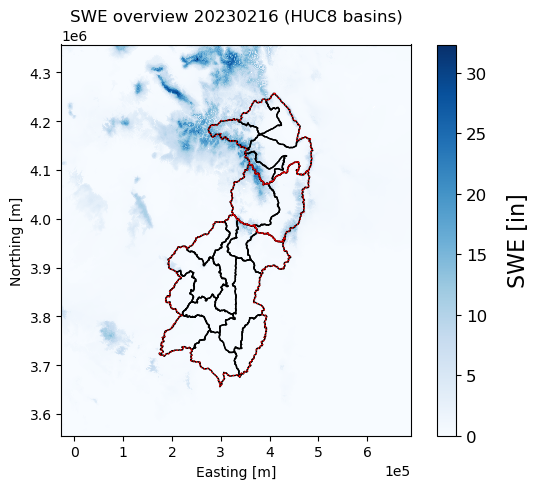

In [15]:
# clip SWE data to HUC8 bounds
bounds = huc8.total_bounds
xpad = 200000
ypad = 100000
bounds_padded = [bounds[0]-xpad, bounds[1]-ypad, bounds[2]+xpad, bounds[3]+ypad]
snodas_clip = snodas_utm.where(snodas_utm>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches

# Plot
fig, ax = plt.subplots(figsize=(6,5))
snodas_clip.plot(ax=ax, cmap='Blues')
cbar = ax.collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
huc8.plot(ax=ax, facecolor='none', edgecolor='k')
huc6.plot(ax=ax, facecolor='none', edgecolor = 'red', linestyle=":")
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('SWE overview ' + date + ' (HUC8 basins)')
plt.tight_layout()

## Loop for SWE calc by basin

In [ ]:
cols_swe = ['Region', 'HUC6 Basin', 'HUC8 Subbasin', 
            'Median SWE (in.)', 'Mean SWE (in.)', 'Estimated Volume (af)', 'Area (acres)']
swe_df = []

for idx, basin in huc8.iterrows():
    #print(basin['Name'])
    swe_basin = snodas_clip.rio.clip([basin.geometry])
    
    '''
    ## plot clipped polygon
    f, ax = plt.subplots()
    swe_basin.plot(cmap="Blues",
                     ax=ax)
    plt.show()'
    '''
    swe_median = np.nanmedian(swe_basin) # median swe basin
    swe_mean = np.nanmean(swe_basin)
    swe_sum_inches = np.nansum(swe_basin) # swe sum basin

    ## get pixel area in feet
    pixel_size_x, pixel_size_y = swe_basin.rio.resolution()
    pixel_area = abs((pixel_size_x*3.28084) * (pixel_size_y*3.28084))
    
    swe_vol_cuft = (swe_sum_inches / 12) * pixel_area # volume in cubic feet
    swe_vol_af = swe_vol_cuft / 43560 # volume in acre feet

    #swe_volume = swe_sum_inches/12 * pd.notnull(swe_basin).sum() / 247.105
    #print(pd.notnull(swe_basin).sum() * 247.105)

    swe_df.append([basin['Region'], basin['HUC6 Basin'],
                   basin['Name'], swe_median, swe_mean,
                   swe_vol_af, basin['AreaAcres']])

swe_df_table = pd.DataFrame(swe_df, columns=cols_swe)
swe_df_table



## Table 1

In [57]:
huc8_stats = swe_stat_calc(snodas_clip, huc8)
huc8_stats = huc8_stats.rename(columns={'name': 'HUC8 SubBasin'}) 
huc8_stats['HUC6 Basin'] = huc6_basin


huc6_stats = swe_stat_calc(snodas_clip, huc6)
huc6_stats = huc6_stats.rename(columns={'name': 'HUC6 Basin'})
huc6_stats['HUC8 SubBasin'] = np.repeat('Total', [3], axis=0)

#huc6_stats
table1 = pd.concat([huc8_stats, huc6_stats], ignore_index=True)
table1 = table1[['HUC6 Basin', 'HUC8 SubBasin', 'Median SWE (in.)', 
                 'Mean SWE (in.)', 'Estimated Volume (af)']]
table1

,HUC6 Basin,HUC8 SubBasin,Median SWE (in.),Mean SWE (in.),Estimated Volume (af)
0,Rio Grande Headwaters,Rio Grande Headwaters,9.055008,9.152621,6.730330e+05
1,Rio Grande Headwaters,Alamosa-Trinchera,0.708653,2.107893,2.850036e+05
2,Rio Grande Headwaters,San Luis,0.354326,1.148413,9.679230e+04
3,Rio Grande Headwaters,Saguache,1.692893,2.469007,1.771338e+05
4,Rio Grande Headwaters,Conejos,7.342431,8.293942,3.391886e+05
5,Upper Rio Grande,Upper Rio Grande,0.708653,2.567760,4.458472e+05
6,Upper Rio Grande,Rio Chama,1.771632,4.002467,6.736127e+05
7,Rio Grande-Elephant Butte,Rio Grande-Santa Fe,0.393696,0.519018,5.185664e+04
8,Rio Grande-Elephant Butte,Jemez,0.511805,2.646449,1.464852e+05
9,Rio Grande-Elephant Butte,Rio Grande-Albuquerque,0.000000,0.039852,6.830176e+03


## Table 2

In [61]:
huc8_ose_polys = ['Rio Grande Headwaters', 'Saguache',
                  'Conejos', 'San Luis',
                  'Alamosa-Trinchera', 'Upper Rio Grande']
huc8_ose = huc8[huc8['Name'].isin(huc8_ose_polys)]

## sort by polygon order
huc8_ose = huc8_ose.set_index('Name', drop = False)
huc8_ose = huc8_ose.reindex(huc8_ose_polys)

## add ose basin column
ose_grouping = np.array(['Upper Rio Grande', 
                       'Sangre de Cristo'])
ose_grouping = np.repeat(ose_grouping, [3, 3], axis=0)

huc8_ose['OSE Grouping'] = ose_grouping

## create table
huc8_ose_stats = swe_stat_calc(snodas_clip, huc8_ose)
huc8_ose_stats = huc8_ose_stats.rename(columns={'name': 'HUC8 SubBasin'}) 
huc8_ose_stats['OSE Grouping'] = ose_grouping


ose_stats = swe_stat_calc(snodas_clip, ose)
ose_stats = ose_stats.rename(columns={'name': 'OSE Grouping'})
ose_stats['HUC8 SubBasin'] = np.repeat('Total', [4], axis=0)

#huc6_stats
table2 = pd.concat([huc8_ose_stats, ose_stats], ignore_index=True)
table2 = table2[['OSE Grouping', 'HUC8 SubBasin', 'Median SWE (in.)', 
                 'Mean SWE (in.)', 'Estimated Volume (af)']]
table2

,OSE Grouping,HUC8 SubBasin,Median SWE (in.),Mean SWE (in.),Estimated Volume (af)
0,Upper Rio Grande,Rio Grande Headwaters,9.055008,9.152621,6.730330e+05
1,Upper Rio Grande,Saguache,1.692893,2.469007,1.771338e+05
2,Upper Rio Grande,Conejos,7.342431,8.293942,3.391886e+05
3,Sangre de Cristo,San Luis,0.354326,1.148413,9.679230e+04
4,Sangre de Cristo,Alamosa-Trinchera,0.708653,2.107893,2.850036e+05
5,Sangre de Cristo,Upper Rio Grande,0.708653,2.567760,4.458472e+05
6,JemezRiver Basin,Total,0.511805,2.642906,1.487381e+05
7,Rio Chama River Basin,Total,1.771632,4.011074,6.755568e+05
8,Sangre De Cristo Mountain Range Basins,Total,0.669283,2.097386,8.260444e+05
9,Upper Rio Grande Basin,Total,4.881830,6.402134,1.185710e+06
